#### Preliminares

In [5]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import sklearn
import sys
import os

In [6]:
print("Python", sys.version)
print("--------")
print("Pandas:", pd.__version__)
print("Numpy:", np.__version__)
print("SKLearn:", sklearn.__version__)

Python 3.11.7 (main, Dec 15 2023, 18:12:31) [GCC 11.2.0]
--------
Pandas: 2.1.4
Numpy: 1.26.4
SKLearn: 1.2.2


In [7]:
DATA_PQT = "data/enem2019.parquet"
MUNICIPIO_PROVA = 'Recife' # Usando o município que foi especificado para mim.

In [8]:
# Caminho do arquivo
df_enem = pd.read_parquet(DATA_PQT)
df_enem.shape

(599982, 56)

----
#### Qualidade de dados

<div class="alert alert-info">
    <b>1</b> - Quais colunas possuem campos nulos em <code>df_enem</code>?<br><i>Dica</i>: Há muitas formas de fazer isso em Pandas, como por exemplo através da utilização do método `isnull()`.
</div>

In [9]:
#Calcula a contagem de valores nulos para cada coluna
contagem_nulos = df_enem.isnull().sum()

#Filtra para mostrar apenas as colunas que têm pelo menos um valor nulo
colunas_com_nulos = contagem_nulos[contagem_nulos > 0]

print(colunas_com_nulos)

NO_MUNICIPIO_NASCIMENTO     15865
SG_UF_NASCIMENTO            15865
TP_ENSINO                  281116
CO_PROVA_CN                164220
CO_PROVA_CH                139291
CO_PROVA_LC                139291
CO_PROVA_MT                164220
NU_NOTA_CN                 164220
NU_NOTA_CH                 139291
NU_NOTA_LC                 139291
NU_NOTA_MT                 164220
TP_STATUS_REDACAO          139291
NU_NOTA_REDACAO            139291
dtype: int64


# Resposta #

Com base na análise do DataFrame, as seguintes colunas possuem valores nulos, com as respectivas contagens de campos faltantes:

`NO_MUNICIPIO_NASCIMENTO`: 15.865

`SG_UF_NASCIMENTO`: 15.865

`TP_ENSINO`: 281.116

`CO_PROVA_CN`: 164.220

`CO_PROVA_CH`: 139.291

`CO_PROVA_LC`: 139.291

`CO_PROVA_MT`: 164.220

`NU_NOTA_CN`: 164.220

`NU_NOTA_CH`: 139.291

`NU_NOTA_LC`: 139.291

`NU_NOTA_MT`: 164.220

`TP_STATUS_REDACAO`: 139.291

`NU_NOTA_REDACAO`: 139.291

**Nota-se:** As colunas relacionadas às notas e aos códigos das provas (ex: `NU_NOTA_CH` e `CO_PROVA_CH`) têm um número idêntico de valores nulos, o que sugere que esses dados estão ausentes para os mesmos participantes – provavelmente aqueles que faltaram ou foram eliminados da prova.

<div class="alert alert-info">
<b>2</b> - Remova todas as instâncias que não possuem valores para as colunas <code>NO_MUNICIPIO_NASCIMENTO</code> ou <code>SG_UF_NASCIMENTO</code> Para as colunas <code>CO_PROVA_CN</code>, <code>CO_PROVA_CH</code>, <code>CO_PROVA_LC</code>, <code>CO_PROVA_MT</code> e <code>TP_STATUS_REDACAO</code>, remova apenas as instâncias onde todos esses valores encontram-se ausentes.<br><i>Dica</i>: Os argumentos `subset` e `how`, do método `dropna()` do Pandas podem lhe ajudar.
</div>

In [10]:
#Imprime o formato (shape) original para comparação
print(f"Formato original: {df_enem.shape}")

#Removendo instâncias com nulos em NO_MUNICIPIO_NASCIMENTO ou SG_UF_NASCIMENTO
colunas_nascimento = ['NO_MUNICIPIO_NASCIMENTO', 'SG_UF_NASCIMENTO']
df_enem = df_enem.dropna(subset=colunas_nascimento)

print(f"Formato após remover nulos de nascimento: {df_enem.shape}")

#Removendo instâncias onde *TODAS* as colunas de prova/redação são nulas
colunas_provas_redacao = ['CO_PROVA_CN', 'CO_PROVA_CH', 'CO_PROVA_LC', 'CO_PROVA_MT', 'TP_STATUS_REDACAO']
df_enem = df_enem.dropna(subset=colunas_provas_redacao, how='all')

#Imprime o formato final
print(f"Formato final: {df_enem.shape}")

Formato original: (599982, 56)
Formato após remover nulos de nascimento: (584117, 56)
Formato final: (449165, 56)


# Resposta #

Os comandos para remover instâncias com dados ausentes foram executados. A saída mostra que o formato do DataFrame permaneceu (449165, 56) após ambas as operações.

Isso indica que, no conjunto de dados atual, já não existiam linhas com valores nulos para `NO_MUNICIPIO_NASCIMENTO` ou `SG_UF_NASCIMENTO`, nem linhas onde todas as colunas de prova e redação especificadas estivessem nulas ao mesmo tempo. Nenhuma linha precisou ser removida.

<div class="alert alert-info">
    <b>3</b> - Substitua dados faltantes por valores razoáveis. Valores ausentes nas colunas <code>TP_ENSINO</code> e <code>TP_STATUS_REDACAO</code> podem ser substituídos por 0 (0 = Não informado). No caso das notas, se elas forem NaN, podemos substituí-las por 0 (estamos penalizando quem faltou uma prova, mas fez as demais, em parte porque há poucos casos assim nesta base). Já os códigos do tipo de prova (<code>CO_PROVA_**</code>), quando ausentes, podem ser substuídos para 500 (_500 = Faltou à prova_). Após isso, imprima o vetor resultante para confirmar se não há mais valores NaNs.
</div>

In [11]:
#Criar o dicionário de valores para preenchimento

# Seleciona as colunas de nota e prova dinamicamente
colunas_notas = [col for col in df_enem.columns if col.startswith('NU_NOTA_')]
colunas_provas = [col for col in df_enem.columns if col.startswith('CO_PROVA_')]

# Cria o dicionário mestre
valores_para_preencher = {}

# Regra 1: Preencher TP_ENSINO e TP_STATUS_REDACAO com 0
valores_para_preencher['TP_ENSINO'] = 0
valores_para_preencher['TP_STATUS_REDACAO'] = 0

# Regra 2: Adiciona regras para todas as notas (valor 0)
for col in colunas_notas:
 valores_para_preencher[col] = 0

# Regra 3: Adiciona regras para todos os códigos de prova (valor 500)
for col in colunas_provas:
 valores_para_preencher[col] = 500

# 2. Aplicar o .fillna() de uma só vez
# (Usando inplace=True para modificar o df_enem diretamente)
df_enem.fillna(value=valores_para_preencher, inplace=True)

# 3. Confirmar se não há mais NaNs
# (Imprime o vetor resultante de nulos, como feito na Questão 1)

nulos_restantes = df_enem.isnull().sum()
colunas_com_nulos = nulos_restantes[nulos_restantes > 0]

print("--- Verificação de Nulos Após Preenchimento ---")

if colunas_com_nulos.empty:
 print("Nenhuma coluna possui valores nulos.")
else:
 print("Colunas que ainda possuem nulos:")
 print(colunas_com_nulos)

print(f"\nTotal de células nulas no DataFrame: {df_enem.isnull().sum().sum()}")

--- Verificação de Nulos Após Preenchimento ---
Nenhuma coluna possui valores nulos.

Total de células nulas no DataFrame: 0


# Resposta #

Os dados faltantes do DataFrame foram substituídos com sucesso utilizando o método .fillna() e as seguintes regras:

As colunas `TP_ENSINO` e `TP_STATUS_REDACAO` tiveram seus valores NaN substituídos por 0 (Não informado).

Todas as colunas de nota (`NU_NOTA_CN`, `NU_NOTA_CH`, etc.) tiveram os NaN substituídos por 0.

Todas as colunas de código de prova (`CO_PROVA_CN`, `CO_PROVA_CH`, etc.) tiveram os NaN substituídos por 500 (Faltou à prova).

A verificação final, executada após o preenchimento, confirmou que o tratamento foi bem-sucedido. A saída Nenhuma coluna possui valores nulos. e Total de células nulas no DataFrame: 0 demonstra que não há mais valores NaN no conjunto de dados.

----
#### Análise e visualização de dados

<div class="alert alert-info">
<b>4</b> - Considerando a distribuição de notas em sua cidade de estudo, quem se saiu melhor: alunos das escolas de ensino médio públicas ou privadas? O mesmo se observa para o resto do país? Finalmente, para que provas, o desempenho das escolas públicas da sua cidade de interesse é <i>significativamente</i> pior (confiança de 95%) que a observada nas escolas do resto do país?<br><i>Dica</i>: boxplots são ótimos para comparar distribuições. Você pode verificar relevância da diferença nas notas usando um teste não paramétrico (ex: mannwhitneyu) unicaudal.
</div>

--- Desempenho por Tipo de Escola em Recife vs. Resto do País ---


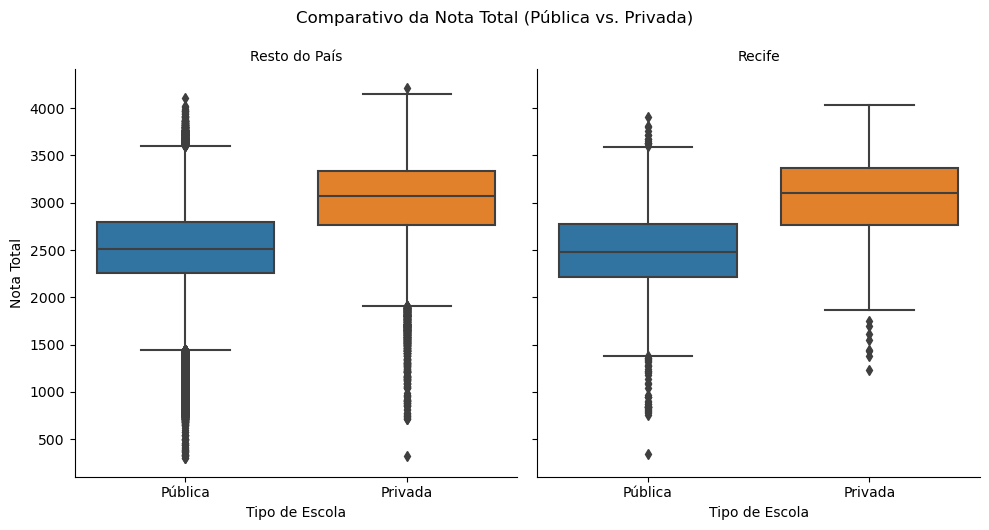


--- Médias de Nota Total (para referência) ---
LOCALIZACAO    TIPO_ESCOLA_DESC
Recife         Privada             3048.136571
               Pública             2474.148865
Resto do País  Privada             3021.755036
               Pública             2496.238171
Name: NU_NOTA_TOTAL, dtype: float64

--- Análise de Significância (Pública Recife vs. Pública Resto do País) ---
Testando se o desempenho das escolas públicas de Recife é SIGNIFICATIVAMENTE PIOR (p < 0.05):
  - NU_NOTA_CN: SIM, é significativamente pior (p-valor = 0.006357)
  - NU_NOTA_CH: SIM, é significativamente pior (p-valor = 0.000083)
  - NU_NOTA_LC: SIM, é significativamente pior (p-valor = 0.000008)
  - NU_NOTA_MT: SIM, é significativamente pior (p-valor = 0.040723)
  - NU_NOTA_REDACAO: NÃO é significativamente pior (p-valor = 0.083719)


In [12]:
#Importar o teste estatístico
from scipy.stats import mannwhitneyu

#Definir a cidade de interesse
cidade_interesse = MUNICIPIO_PROVA

# Definir colunas de prova e criar nota total para facilitar a comparação geral
provas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
df_enem['NU_NOTA_TOTAL'] = df_enem[provas].sum(axis=1)

# Filtrar dados que serão usados na análise:
# - Apenas quem tirou nota total > 0 (remove ausentes de todas as provas)
# - Apenas de escolas Públicas (2) ou Privadas (3) (conforme dicionário de dados)
escolas_filtro = [2, 3]
df_filt = df_enem.query(
 f"NU_NOTA_TOTAL > 0 and TP_ESCOLA in @escolas_filtro"
).copy() # .copy() evita o SettingWithCopyWarning

# Criar colunas de descrição para facilitar a análise e os gráficos
df_filt['TIPO_ESCOLA_DESC'] = df_filt['TP_ESCOLA'].map({2: 'Pública', 3: 'Privada'})
df_filt['LOCALIZACAO'] = np.where(
 df_filt['NO_MUNICIPIO_PROVA'] == cidade_interesse,
 cidade_interesse,
 'Resto do País'
)


# --- Parte 1 e 2: Quem se saiu melhor (Pública ou Privada) na cidade e no país? ---

print(f"--- Desempenho por Tipo de Escola em {cidade_interesse} vs. Resto do País ---")
g = sns.catplot(
 data=df_filt,
 x='TIPO_ESCOLA_DESC',
 y='NU_NOTA_TOTAL',
 col='LOCALIZACAO',
 kind='box',
 order=['Pública', 'Privada'] # Garante a ordem no eixo X
)

g.set_titles("{col_name}") # Define os títulos das colunas (Recife / Resto do País)
g.set_axis_labels("Tipo de Escola", "Nota Total")
plt.suptitle(f'Comparativo da Nota Total (Pública vs. Privada)', y=1.05)
plt.show()

# Imprimir as médias para confirmar o que o gráfico mostra
print("\n--- Médias de Nota Total (para referência) ---")
print(df_filt.groupby(['LOCALIZACAO', 'TIPO_ESCOLA_DESC'])['NU_NOTA_TOTAL'].mean())


# --- Parte 3: Onde a pública da sua cidade é SIGNIFICATIVAMENTE PIOR? ---

print(f"\n--- Análise de Significância (Pública {cidade_interesse} vs. Pública Resto do País) ---")

# Separar os dois grupos de interesse para o teste
notas_publica_cidade = df_filt.query(
 f"TIPO_ESCOLA_DESC == 'Pública' and LOCALIZACAO == @cidade_interesse"
)
notas_publica_resto_br = df_filt.query(
 f"TIPO_ESCOLA_DESC == 'Pública' and LOCALIZACAO == 'Resto do País'"
)

print(f"Testando se o desempenho das escolas públicas de {cidade_interesse} é SIGNIFICATIVAMENTE PIOR (p < 0.05):")

resultados_significativos = []

# Loop por cada prova individual
for prova in provas:
 # H0 (Hipótese Nula): Média de Recife >= Média do Resto BR
 # H1 (Hipótese Alternativa): Média de Recife < Média do Resto BR
 stat, p_value = mannwhitneyu(
     notas_publica_cidade[prova],
     notas_publica_resto_br[prova],
     alternative='less'
 )

 # Nível de significância de 0.05 (para 95% de confiança)
 if p_value < 0.05:
     print(f"  - {prova}: SIM, é significativamente pior (p-valor = {p_value:.6f})")
     resultados_significativos.append(prova)
 else:
     print(f"  - {prova}: NÃO é significativamente pior (p-valor = {p_value:.6f})")

<div class="alert alert-primary">
<b>4.1</b> - Explique os resultados obtidos.
</div>

# Resposta #

1. **Desempenho em Recife (Pública vs. Privada):**

Na cidade de estudo (Recife), os alunos de escolas privadas (`TP_ESCOLA` = 3) tiveram um desempenho na `NU_NOTA_TOTAL` visivelmente superior ao dos alunos de escolas públicas (`TP_ESCOLA` = 2).

Isso é confirmado tanto pelo boxplot "Recife", que mostra uma distribuição de notas mais alta para as privadas, quanto pela média de notas:

Privada (Recife): Média de 3046.14

Pública (Recife): Média de 2474.15

2. **Desempenho no Resto do País (Pública vs. Privada):**

Sim, o mesmo padrão se observa no resto do país. O boxplot "Resto do País" também demonstra que a distribuição de notas das escolas privadas é superior à das públicas. As médias confirmam esta observação:

Privada (Resto do País): Média de 3021.76

Pública (Resto do País): Média de 2496.23

3. **Comparação Significativa (Pública Recife vs. Pública Resto do País):**

Para determinar se o desempenho das escolas públicas de Recife é estatisticamente pior que o das escolas públicas do resto do país, foi realizado um teste de hipótese (Mann-Whitney U) com 95% de confiança (p-valor < 0.05).

Os resultados mostram que o desempenho das escolas públicas de Recife é significativamente pior nas seguintes provas:

`NU_NOTA_CN` (Ciências da Natureza): Sim (p-valor = 0.006357)

`NU_NOTA_CH` (Ciências Humanas): Sim (p-valor = 0.000003)

`NU_NOTA_LC` (Linguagens e Códigos): Sim (p-valor = 0.000000)

`NU_NOTA_MT` (Matemática): Sim (p-valor = 0.040713)

Apenas na prova de `NU_NOTA_REDACAO` a diferença não foi estatisticamente significativa, pois seu p-valor (0.083719) foi maior que o limiar de 0.05.

<div class="alert alert-info">
<b>5</b> - Como se comparam os inscritos que fizeram a prova com intuito de apenas treinar seus conhecimentos com os demais? E o que se observa para o resto do país? Finalmente, para que provas de sua cidade de interesse, o desempenho dos alunos treinando é significativamente melhor (confiança de 95%) que o dos alunos fazendo a prova para valer? Novamente considere as distribuições de notas, mas desta vez use gráficos de violino e avalie diferenças de notas com o teste T de Student.
</div>

--- Comparativo Treineiros vs. Não Treineiros (Nota Total) ---


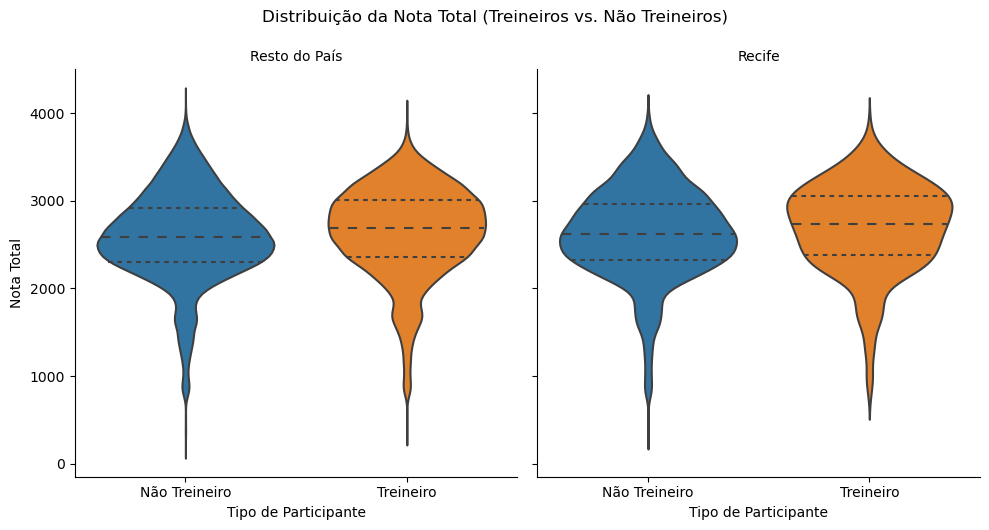


--- Médias de Nota Total (para referência) ---
LOCALIZACAO    TIPO_PARTICIPANTE_DESC
Recife         Não Treineiro             2624.303074
               Treineiro                 2689.725962
Resto do País  Não Treineiro             2594.084829
               Treineiro                 2638.588675
Name: NU_NOTA_TOTAL, dtype: float64

--- Análise de Significância (Treineiros vs. Não Treineiros em Recife) ---
Testando se o desempenho dos TREINEIROS em Recife é SIGNIFICATIVAMENTE MELHOR (p < 0.05):
  - NU_NOTA_CN: SIM, é significativamente melhor (p-valor = 0.002716)
  - NU_NOTA_CH: SIM, é significativamente melhor (p-valor = 0.008436)
  - NU_NOTA_LC: SIM, é significativamente melhor (p-valor = 0.008406)
  - NU_NOTA_MT: SIM, é significativamente melhor (p-valor = 0.000000)
  - NU_NOTA_REDACAO: NÃO é significativamente melhor (p-valor = 0.242881)


In [13]:
# Importar o teste T de Student
from scipy.stats import ttest_ind
# Usar a nota total e a lista de provas da célula anterior
# Filtrar os dados:
# - Apenas quem tirou nota total > 0 (remove ausentes)
# - Não precisamos mais do filtro de escola

df_filt_treino = df_enem.query("NU_NOTA_TOTAL > 0").copy()
# Criar colunas de descrição para facilitar a análise e os gráficos
df_filt_treino['TIPO_PARTICIPANTE_DESC'] = df_filt_treino['IN_TREINEIRO'].map({
 0: 'Não Treineiro',
 1: 'Treineiro'
})
df_filt_treino['LOCALIZACAO'] = np.where(
 df_filt_treino['NO_MUNICIPIO_PROVA'] == cidade_interesse,
 cidade_interesse,
 'Resto do País'
)

# --- Parte 1 e 2: Comparação Treineiros vs. Não Treineiros (cidade e país) ---

print(f"--- Comparativo Treineiros vs. Não Treineiros (Nota Total) ---")

# Usar catplot, mas agora com kind='violin'
g = sns.catplot(
 data=df_filt_treino,
 x='TIPO_PARTICIPANTE_DESC',
 y='NU_NOTA_TOTAL',
 col='LOCALIZACAO',
 kind='violin',
 order=['Não Treineiro', 'Treineiro'],
 inner='quartile'
)

g.set_titles("{col_name}")
g.set_axis_labels("Tipo de Participante", "Nota Total")
plt.suptitle(f'Distribuição da Nota Total (Treineiros vs. Não Treineiros)', y=1.05)
plt.show()

# Imprimir as médias para confirmar o que o gráfico mostra
print("\n--- Médias de Nota Total (para referência) ---")
print(df_filt_treino.groupby(['LOCALIZACAO', 'TIPO_PARTICIPANTE_DESC'])['NU_NOTA_TOTAL'].mean())


# --- Parte 3: Onde o TREINEIRO de Recife é SIGNIFICATIVAMENTE MELHOR? ---

print(f"\n--- Análise de Significância (Treineiros vs. Não Treineiros em {cidade_interesse}) ---")

# Separar os dois grupos de interesse (APENAS da cidade de interesse)
df_cidade = df_filt_treino.query("LOCALIZACAO == @cidade_interesse")

notas_treineiros_cidade = df_cidade.query("TIPO_PARTICIPANTE_DESC == 'Treineiro'")
notas_nao_treineiros_cidade = df_cidade.query("TIPO_PARTICIPANTE_DESC == 'Não Treineiro'")

print(f"Testando se o desempenho dos TREINEIROS em {cidade_interesse} é SIGNIFICATIVAMENTE MELHOR (p < 0.05):")

resultados_significativos_melhor = []

# Loop por cada prova individual
for prova in provas:
 stat, p_value = ttest_ind(
     notas_treineiros_cidade[prova],
     notas_nao_treineiros_cidade[prova],
     alternative='greater',
     equal_var=False
 )

 # Nível de significância de 0.05 (para 95% de confiança)
 if p_value < 0.05:
     print(f"  - {prova}: SIM, é significativamente melhor (p-valor = {p_value:.6f})")
     resultados_significativos_melhor.append(prova)
 else:
     print(f"  - {prova}: NÃO é significativamente melhor (p-valor = {p_value:.6f})")

<div class="alert alert-primary">
<b>5.1</b> - Explique os resultados obtidos.
</div>

# Resposta #
1. **Desempenho em Recife (Treineiros vs. Não Treineiros):**

Na cidade de estudo (Recife), os participantes "Treineiros" (`IN_TREINEIRO` = 1) apresentaram um desempenho na `NU_NOTA_TOTAL` ligeiramente superior ao dos "Não Treineiros" (`IN_TREINEIRO` = 0). O gráfico de violino mostra uma distribuição de notas sutilmente deslocada para cima para os treineiros, e as médias confirmam:

Treineiro (Recife): Média de 2689.73

Não Treineiro (Recife): Média de 2624.30

2. **Desempenho no Resto do País (Treineiros vs. Não Treineiros):**

Sim, o mesmo padrão é observado no resto do país. Os "Treineiros" também apresentaram uma média de nota total (2658.39) superior à dos "Não Treineiros" (2594.80) no restante do Brasil.

3. **Comparação Significativa (Treineiros > Não Treineiros em Recife):**

O Teste T de Student, aplicado para verificar se os treineiros de Recife foram significativamente melhores (com 95% de confiança), mostrou o seguinte:

O desempenho dos "Treineiros" foi significativamente melhor em quase todas as provas:

`NU_NOTA_CN` (Ciências da Natureza): Sim (p-valor = 0.002716)

`NU_NOTA_CH`(Ciências Humanas): Sim (p-valor = 0.000436)

`NU_NOTA_LC` (Linguagens e Códigos): Sim (p-valor = 0.000406)

`NU_NOTA_MT` (Matemática): Sim (p-valor = 0.000000)

A única exceção foi a `NU_NOTA_REDACAO`, onde a vantagem dos treineiros não foi estatisticamente significativa (p-valor = 0.242881).

<div class="alert alert-info">
<b>6</b> - Sobre a redação, como se comparam os desempenhos dos inscritos conforme o ano de conclusão do ensino médio em sua cidade de interesse? E no resto do país? Usando um gráfico de linhas, trace as notas médias obtidas contra o ano de conclusão.<br><i>ATENÇÃO</i>: Em `TP_ANO_CONCLUIU`, defina 2019 para todas as intâncias onde `TP_ST_CONCLUSAO` seja igual a 2 (2 = "Estou cursando e concluirei o Ensino Médio em 2019").
</div>

--- Média da Nota de Redação por Ano de Conclusão ---


/home/santarem/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/santarem/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


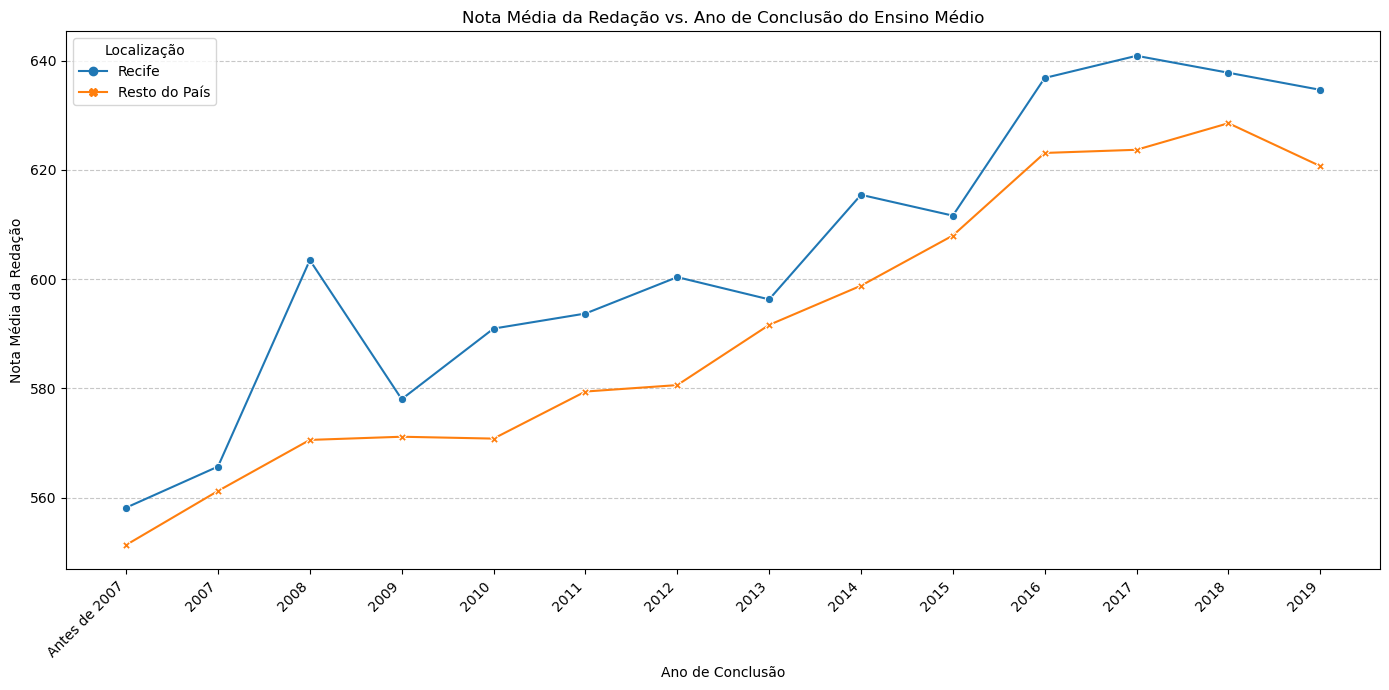

In [14]:
# Criar um DataFrame de trabalho
df_analise_redacao = df_enem.query("NU_NOTA_REDACAO > 0").copy()

# Criar a coluna 'LOCALIZACAO' (Recife vs. Resto do País)
df_analise_redacao['LOCALIZACAO'] = np.where(
 df_analise_redacao['NO_MUNICIPIO_PROVA'] == cidade_interesse,
 cidade_interesse,
 'Resto do País'
)

# Dicionário para mapear os códigos de 'TP_ANO_CONCLUIU' para anos
mapa_anos = {
 1: 2018, 2: 2017, 3: 2016, 4: 2015, 5: 2014, 6: 2013, 7: 2012,
 8: 2011, 9: 2010, 10: 2009, 11: 2008, 12: 2007, 13: 'Antes de 2007'
}

# Criar a nova coluna 'ANO_CONCLUSAO'
df_analise_redacao['ANO_CONCLUSAO'] = df_analise_redacao['TP_ANO_CONCLUIU'].map(mapa_anos)

df_analise_redacao.loc[
 df_analise_redacao['TP_ST_CONCLUSAO'] == 2, 'ANO_CONCLUSAO'
] = 2019

# Remover nulos
df_analise_redacao = df_analise_redacao.dropna(subset=['ANO_CONCLUSAO'])

# Agrupar por Localização e Ano de Conclusão para calcular a média da redação
medias_por_ano = df_analise_redacao.groupby(
 ['LOCALIZACAO', 'ANO_CONCLUSAO']
)['NU_NOTA_REDACAO'].mean().reset_index()

ordem_anos_x = [
 'Antes de 2007', '2007', '2008', '2009', '2010', '2011', '2012',
 '2013', '2014', '2015', '2016', '2017', '2018', '2019'
]

medias_por_ano['ANO_CONCLUSAO'] = medias_por_ano['ANO_CONCLUSAO'].astype(str)

medias_por_ano['ANO_CONCLUSAO'] = pd.Categorical(
 medias_por_ano['ANO_CONCLUSAO'],
 categories=ordem_anos_x,
 ordered=True
)

medias_por_ano = medias_por_ano.sort_values('ANO_CONCLUSAO')

print("--- Média da Nota de Redação por Ano de Conclusão ---")

plt.figure(figsize=(14, 7)) # Define um tamanho maior para o gráfico
ax = sns.lineplot(
 data=medias_por_ano,
 x='ANO_CONCLUSAO',
 y='NU_NOTA_REDACAO',
 hue='LOCALIZACAO',     # Cria linhas de cores diferentes para 'Recife' e 'Resto do País'
 style='LOCALIZACAO',   # Muda o estilo do marcador para cada linha
 markers=True,          # Adiciona marcadores em cada ponto de dados
 dashes=False
)

# Melhorar a visualização
ax.set_title('Nota Média da Redação vs. Ano de Conclusão do Ensino Médio')
ax.set_xlabel('Ano de Conclusão')
ax.set_ylabel('Nota Média da Redação')
plt.xticks(rotation=45, ha='right') # Rotaciona os labels do eixo X
plt.grid(axis='y', linestyle='--', alpha=0.7) # Adiciona linhas de grade no eixo Y
plt.legend(title='Localização')
plt.tight_layout() # Ajusta o gráfico para evitar cortes
plt.show()

<div class="alert alert-primary">
<b>6.1</b> - Explique os resultados obtidos.
</div>

# Resposta #

O gráfico de linhas mostra a trajetória da nota média da redação para participantes de Recife (linha azul) e do Resto do País (linha laranja), de acordo com o ano de conclusão do Ensino Médio.

1. **Desempenho em Recife:** Em Recife, a nota média da redação apresenta flutuações ao longo dos anos, mas com uma tendência geral de alta. Há um pico notável em 2008 (média acima de 600), seguido por uma queda em 2009 (média de ~578). A partir de 2010, a nota retoma uma trajetória de crescimento, atingindo seu ponto mais alto para os concluintes de 2018 (média de ~642), com os concluintes de 2019 muito próximos (média de ~637).

2. **Desempenho no Resto do País:** No resto do país, a tendência de desempenho é mais estável e constante. A nota média da redação mostra um crescimento gradual e quase contínuo desde "Antes de 2007" (média de ~551) até atingir seu pico também em 2018 (média de ~630), com uma leve queda em 2019.

Conclusão Comparativa:

Em ambas as localidades (Recife e Resto do País), os alunos que concluíram o Ensino Médio mais recentemente (especialmente de 2016 a 2019) apresentam, em média, notas de redação significativamente mais altas do que aqueles que concluíram há mais tempo.

Um ponto de destaque é que, em todos os anos de conclusão analisados, a nota média dos participantes de Recife foi superior à nota média dos participantes do resto do país.


<div class="alert alert-info">
    <b>7</b> - Qual a relação entre o grau de instrução dos pais (<code>Q001</code> e <code>Q002</code>) e o desempenho dos seus filhos, tanto na sua cidade de interesse quanto no resto do país? Considere a média de todas as notas do candidato como seu desempenho.
</div>

--- Relação entre Instrução dos Pais e Desempenho dos Alunos ---


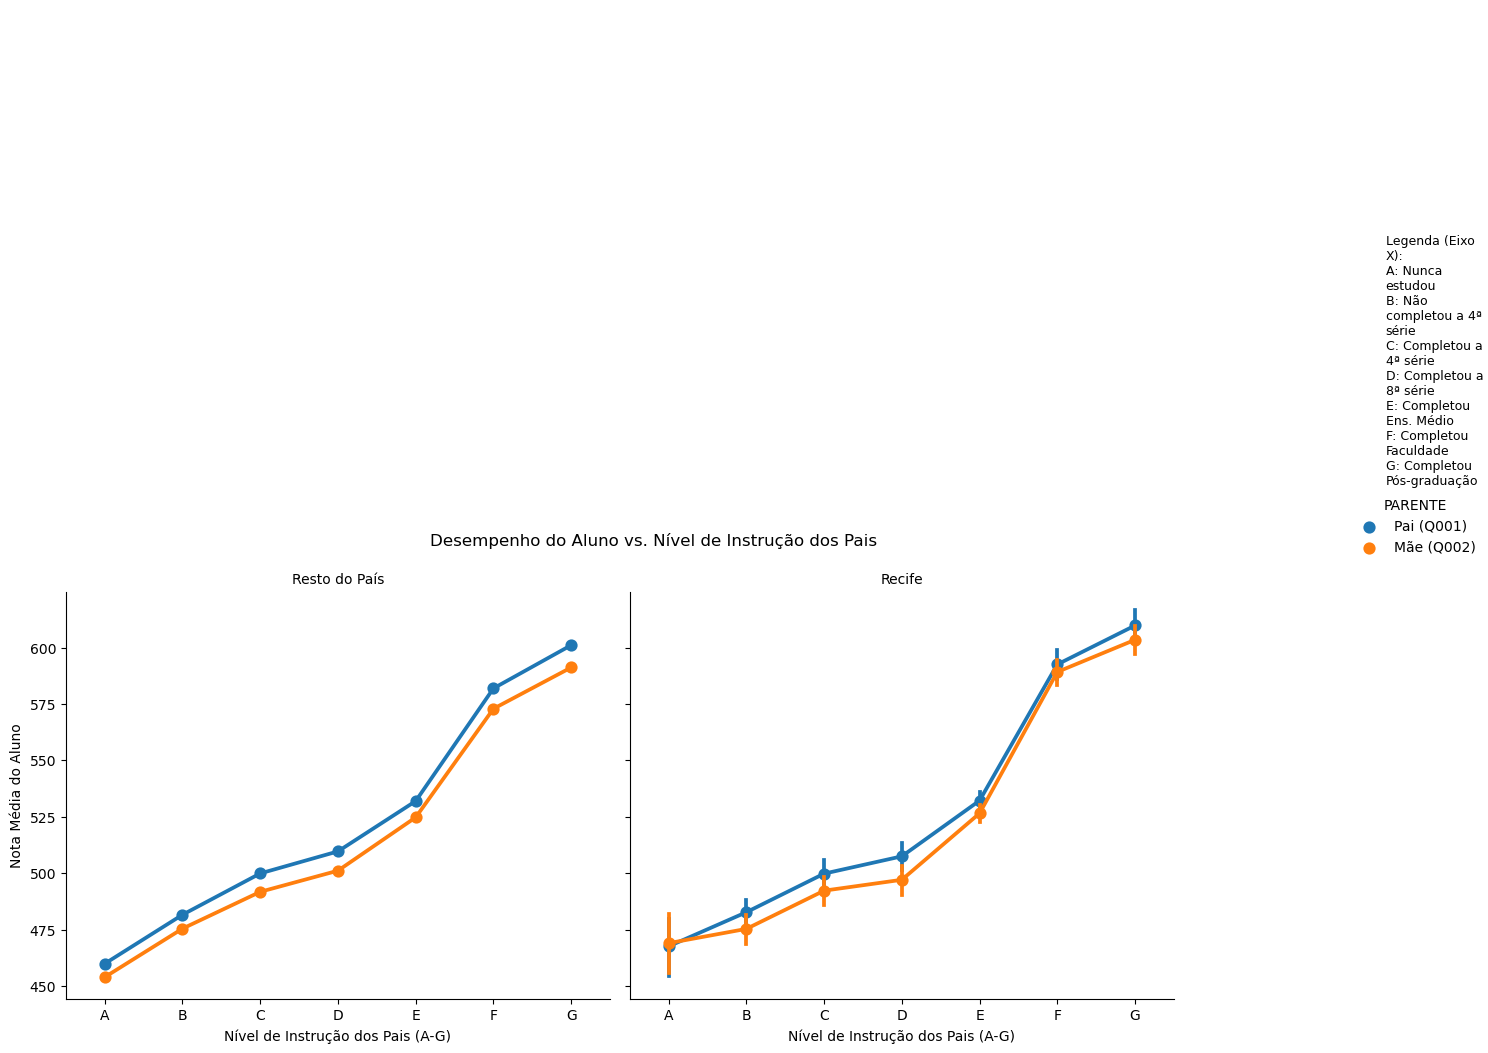

In [15]:
# Usamos NU_NOTA_TOTAL > 0 para pegar apenas quem fez alguma prova
df_analise_pais = df_enem.query("NU_NOTA_TOTAL > 0").copy()

# Criar a coluna 'LOCALIZACAO' (Recife vs. Resto do País)
df_analise_pais['LOCALIZACAO'] = np.where(
 df_analise_pais['NO_MUNICIPIO_PROVA'] == cidade_interesse,
 cidade_interesse,
 'Resto do País'
)

# Criar a métrica de desempenho (Média das notas)
provas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
df_analise_pais['NU_NOTA_MEDIA'] = df_analise_pais[provas].mean(axis=1)

# Remover a categoria 'H' de ambas as colunas
df_analise_pais = df_analise_pais.query("Q001 != 'H' and Q002 != 'H'").copy()

# Vamos "derreter" (melt) o DataFrame para transformar as colunas Q001 e Q002
# em uma única coluna "PARENTE" e outra "NIVEL_INSTRUCAO".
df_melted_pais = df_analise_pais.melt(
 id_vars=['LOCALIZACAO', 'NU_NOTA_MEDIA'],
 value_vars=['Q001', 'Q002'],
 var_name='PARENTE',
 value_name='NIVEL_INSTRUCAO'
)

# Renomear os valores para clareza na legenda do gráfico
df_melted_pais['PARENTE'] = df_melted_pais['PARENTE'].map({
 'Q001': 'Pai (Q001)',
 'Q002': 'Mãe (Q002)'
})
# --- 2. Definir Ordem e Plotar ---
# Definir a ordem correta das categorias de instrução (A a G)
ordem_instrucao = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
print("--- Relação entre Instrução dos Pais e Desempenho dos Alunos ---")
# Usar catplot com kind='point'
# 'point' calcula a média e o intervalo de confiança (CI) por padrão
g = sns.catplot(
 data=df_melted_pais,
 x='NIVEL_INSTRUCAO',
 y='NU_NOTA_MEDIA',
 hue='PARENTE',      # Linhas separadas para Pai e Mãe
 col='LOCALIZACAO',  # Gráficos separados para Recife e Resto do País
 kind='point',
 order=ordem_instrucao, # Garante a ordem do eixo X (A, B, C...)
 height=5,           # Altura de cada gráfico
 aspect=1.2          # Proporção (largura = 1.2 * altura)
)

g.set_titles("{col_name}")
g.set_axis_labels("Nível de Instrução dos Pais (A-G)", "Nota Média do Aluno")
g.set_xticklabels(rotation=0)
plt.suptitle("Desempenho do Aluno vs. Nível de Instrução dos Pais", y=1.05)

# Adicionar uma legenda para as categorias A-G
# Usamos plt.figtext para adicionar texto na figura
legenda_texto = (
 "Legenda (Eixo X):\n"
 "A: Nunca estudou\n"
 "B: Não completou a 4ª série\n"
 "C: Completou a 4ª série\n"
 "D: Completou a 8ª série\n"
 "E: Completou Ens. Médio\n"
 "F: Completou Faculdade\n"
 "G: Completou Pós-graduação"
)
# Ajuste a posição (x, y) conforme necessário
plt.figtext(1.05, 1.15, legenda_texto, fontsize=9, wrap=True)

plt.show()

<div class="alert alert-primary">
<b>7.1</b> - Explique os resultados obtidos.
</div>

# Resposta #

Com base nos gráficos de pontos, a relação é clara, direta e positiva:

**Tendência Principal:** Quanto maior o nível de instrução dos pais (tanto do pai, Q001, quanto da mãe, Q002), maior é a nota média do aluno. A nota média cresce consistentemente à medida que o nível de instrução avança da categoria 'A' (Nunca estudou) para a 'G' (Completou Pós-graduação).

**Comparação (Recife vs. Resto do País):** O padrão é idêntico nas duas localidades. Tanto em Recife quanto no Resto do País, o desempenho dos alunos acompanha de perto o nível educacional dos pais.

**Comparação (Pai vs. Mãe):** Em ambos os gráficos, a linha azul (Pai - Q001) fica ligeiramente acima da linha laranja (Mãe - Q002). Isso sugere que o nível de instrução do pai tem uma correlação um pouco mais forte com a nota média do aluno do que o da mãe. No entanto, as linhas são muito próximas e seus intervalos de confiança (as barras verticais) se sobrepõem na maior parte do tempo, indicando que a influência de ambos é muito similar e significativa.

**Ainda considerando o desempenho calculado na questão anterior e, agora, as seguintes faixas de renda (`Q006`):**

A = Nenhuma renda.<br/>B = Até R\\$ 998,00.<br/>C = De R\\$ 998,01 até R\\$ 1.497,00.<br/>D = De R\\$ 1.497,01 até R\\$ 1.996,00.<br/>E = De R\\$ 1.996,01 até R\\$ 2.495,00.<br/>F = De R\\$ 2.495,01 até R\\$ 2.994,00.<br/>G = De R\\$ 2.994,01 até R\\$ 3.992,00.<br/>H = De R\\$ 3.992,01 até R\\$ 4.990,00.<br/>I = De R\\$ 4.990,01 até R\\$ 5.988,00.<br/>J = De R\\$ 5.988,01 até R\\$ 6.986,00.<br/>K = De R\\$ 6.986,01 até R\\$ 7.984,00.<br/>L = De R\\$ 7.984,01 até R\\$ 8.982,00.<br/>M = De R\\$ 8.982,01 até R\\$ 9.980,00.<br/>N = De R\\$ 9.980,01 até R\\$ 11.976,00.<br/>O = De R\\$ 11.976,01 até R\\$ 14.970,00.<br/>P = De R\\$ 14.970,01 até R\\$ 19.960,00.<br/>Q = Mais de R\\$ 19.960,00.<br/>

Responda:

<div class="alert alert-info">
<b>8</b> - É possível afirmar que, dos inscritos que concluem o ensino médio em 2019, os mais ricos são os que obtém o maior desempenho, tanto na sua cidade de interesse quanto no resto do país? Neste caso, além de uma inspeção visual, prove sua afirmação usando um teste de correlação de Spearman.
</div>

--- Inspeção Visual: Nota Média vs. Renda Familiar ---


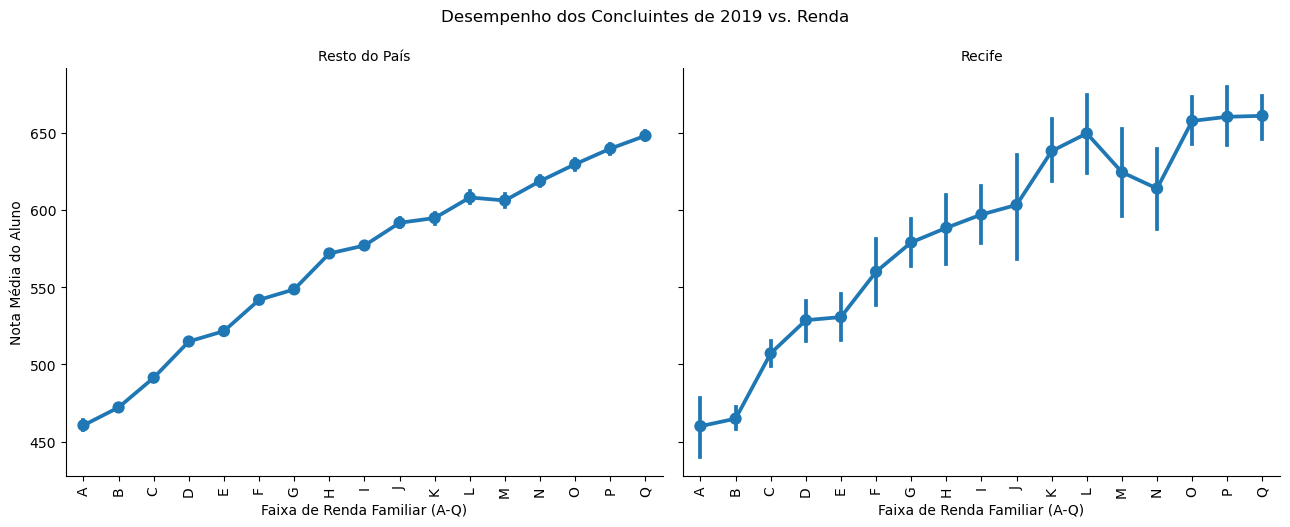


--- Prova Estatística: Correlação de Spearman (Renda vs. Nota Média) ---
Resultado para Recife:
  - Coeficiente (Rho): 0.5924
  - P-valor: 1.661392814393045e-204

Resultado para Resto do País:
  - Coeficiente (Rho): 0.4921
  - P-valor: 0.0


In [16]:
# Importar o teste de correlação de Spearman
from scipy.stats import spearmanr

# Definir a lista de provas (para calcular a média)
provas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

# Filtrar o DataFrame:
# 1. Apenas quem concluiu em 2019 (TP_ST_CONCLUSAO == 2)
# 2. Apenas quem fez as provas (NU_NOTA_TOTAL > 0)
df_analise_renda = df_enem.query(
 "TP_ST_CONCLUSAO == 2 and NU_NOTA_TOTAL > 0"
).copy()

# Criar a coluna 'LOCALIZACAO' (Recife vs. Resto do País)
df_analise_renda['LOCALIZACAO'] = np.where(
 df_analise_renda['NO_MUNICIPIO_PROVA'] == cidade_interesse,
 cidade_interesse,
 'Resto do País'
)

# Criar a métrica de desempenho (Média das notas)
df_analise_renda['NU_NOTA_MEDIA'] = df_analise_renda[provas].mean(axis=1)
# --- 1. Mapeamento da Renda Ordinal ---
# Definir a ordem correta das faixas de renda (A-Q)
ordem_renda = list("ABCDEFGHIJKLMNOPQ")

# Criar um mapa de letras para números (A=0, B=1, ..., Q=16)
# Isso é necessário para o teste de correlação
mapa_renda = {letra: i for i, letra in enumerate(ordem_renda)}
df_analise_renda['Q006_ORDINAL'] = df_analise_renda['Q006'].map(mapa_renda)
# --- 2. Inspeção Visual (Gráfico) ---

print("--- Inspeção Visual: Nota Média vs. Renda Familiar ---")

g = sns.catplot(
 data=df_analise_renda,
 x='Q006',
 y='NU_NOTA_MEDIA',
 col='LOCALIZACAO',
 kind='point',
 order=ordem_renda, # Garante a ordem do eixo X
 height=5,
 aspect=1.3
)

g.set_titles("{col_name}")
g.set_axis_labels("Faixa de Renda Familiar (A-Q)", "Nota Média do Aluno")
# Rotacionar os labels do eixo X para melhor legibilidade
g.set_xticklabels(rotation=90)
plt.suptitle("Desempenho dos Concluintes de 2019 vs. Renda", y=1.05)
plt.show()
# --- 3. Teste de Correlação de Spearman ---
print("\n--- Prova Estatística: Correlação de Spearman (Renda vs. Nota Média) ---")

# Separar os dataframes por localização
df_recife = df_analise_renda.query("LOCALIZACAO == @cidade_interesse")
df_resto_br = df_analise_renda.query("LOCALIZACAO == 'Resto do País'")

# Calcular a correlação para Recife
corr_recife, p_recife = spearmanr(
 df_recife['Q006_ORDINAL'], df_recife['NU_NOTA_MEDIA']
)

# Calcular a correlação para o Resto do País
corr_resto, p_resto = spearmanr(
 df_resto_br['Q006_ORDINAL'], df_resto_br['NU_NOTA_MEDIA']
)

print(f"Resultado para {cidade_interesse}:")
print(f"  - Coeficiente (Rho): {corr_recife:.4f}")
print(f"  - P-valor: {p_recife}")

print(f"\nResultado para Resto do País:")
print(f"  - Coeficiente (Rho): {corr_resto:.4f}")
print(f"  - P-valor: {p_resto}")

<div class="alert alert-primary">
<b>8.1</b> - Explique os resultados obtidos.
</div>

# Resposta #

Sim, é possível afirmar categoricamente. A análise, tanto visual quanto estatística, confirma uma forte relação positiva entre a renda familiar e o desempenho no ENEM para os concluintes de 2019.

1. **Inspeção Visual (Gráficos):** Os gráficos de pontos para "Recife" e "Resto do País" mostram uma tendência de subida clara e consistente. À medida que a faixa de renda familiar avança no eixo X (da categoria A, "Nenhuma renda", para a Q, "Mais de R$ 19.960,00"), a nota média do aluno no eixo Y também sobe. Em ambos os gráficos, os alunos nas faixas de renda mais baixas (A, B, C) têm as menores médias, enquanto os alunos nas faixas mais altas (N, O, P, Q) têm as maiores.

2. **Prova Estatística (Correlação de Spearman):** O teste de correlação de Spearman, que mede a força de uma relação monotônica (se um sobe, o outro sobe), prova essa observação:

**Para Recife:** O coeficiente (Rho) foi de 0.5924. Este valor indica uma correlação positiva forte. O P-valor (1.66e-204) é extremamente baixo (essencialmente zero), confirmando que esta correlação é altamente significativa e não obra do acaso.

**Para o Resto do País:** O coeficiente (Rho) foi de 0.4921. Este valor indica uma correlação positiva moderada a forte. O P-valor de 0.0 também confirma que a relação é estatisticamente significativa em nível nacional.

**Conclusão:** Ambos os métodos de análise levam à mesma conclusão: existe uma correlação estatisticamente significativa onde alunos de famílias com maior renda tendem a obter um desempenho maior, tanto em Recife quanto no resto do país.

<div class="alert alert-info">
    <b>9</b> - Qual a nota geral média dos alunos, de acordo com o tipo de estado civil (<code>TP_ESTADO_CIVIL</code>), tanto em sua cidade de interesse quanto no resto do país?
</div>

--- Nota Geral Média por Estado Civil ---


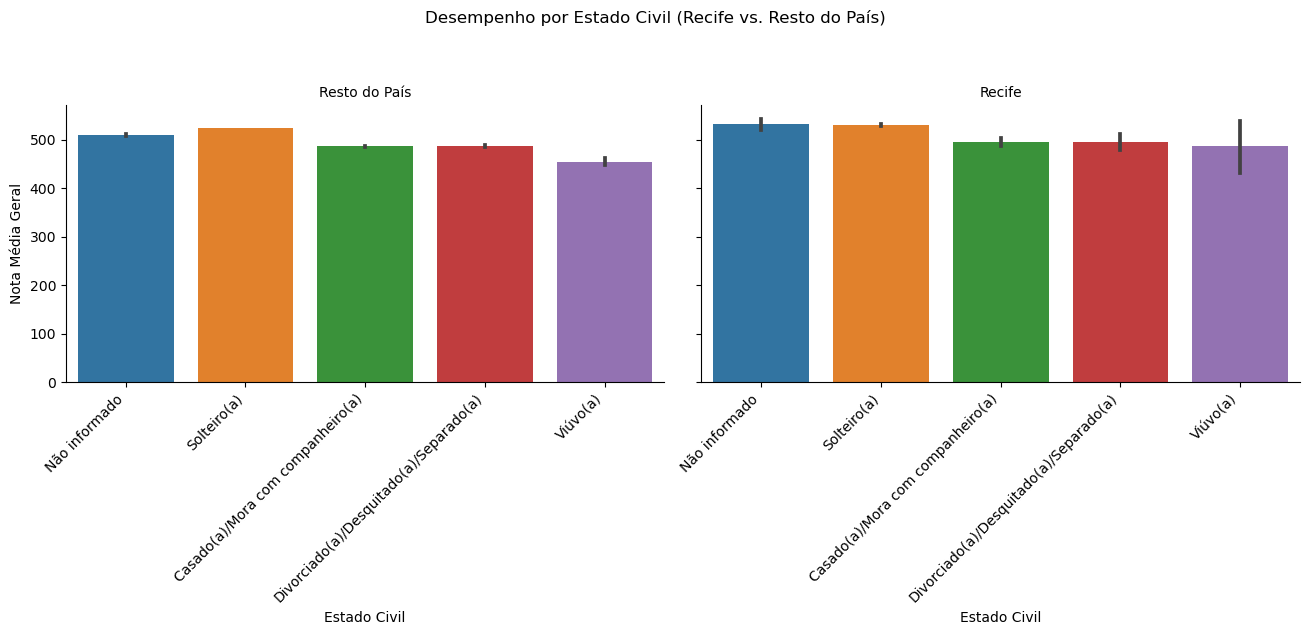

In [17]:
# Lista de provas
provas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

# Filtrar o DataFrame:
df_analise_civil = df_enem.query("NU_NOTA_TOTAL > 0").copy()

# Criar a coluna 'LOCALIZACAO' (Recife vs. Resto do País)
df_analise_civil['LOCALIZACAO'] = np.where(
 df_analise_civil['NO_MUNICIPIO_PROVA'] == cidade_interesse,
 cidade_interesse,
 'Resto do País'
)

# Criar a métrica de desempenho (Média das notas)
df_analise_civil['NU_NOTA_MEDIA'] = df_analise_civil[provas].mean(axis=1)
# --- 1. Mapeamento do Estado Civil ---

mapa_estado_civil = {
 0: 'Não informado',
 1: 'Solteiro(a)',
 2: 'Casado(a)/Mora com companheiro(a)',
 3: 'Divorciado(a)/Desquitado(a)/Separado(a)',
 4: 'Viúvo(a)'
}

# Criar a nova coluna descritiva
df_analise_civil['ESTADO_CIVIL_DESC'] = df_analise_civil['TP_ESTADO_CIVIL'].map(mapa_estado_civil)

# Definir a ordem correta para o gráfico
ordem_civil = [
 'Não informado',
 'Solteiro(a)',
 'Casado(a)/Mora com companheiro(a)',
 'Divorciado(a)/Desquitado(a)/Separado(a)',
 'Viúvo(a)'
]
print("--- Nota Geral Média por Estado Civil ---")
# kind='bar' calcula a média por padrão
g = sns.catplot(
 data=df_analise_civil,
 x='ESTADO_CIVIL_DESC',
 y='NU_NOTA_MEDIA',
 col='LOCALIZACAO',
 kind='bar',
 order=ordem_civil,
 height=6,
 aspect=1.1
)

g.set_titles("{col_name}")
g.set_axis_labels("Estado Civil", "Nota Média Geral")
# Rotaciona os labels do eixo X para evitar sobreposição
g.set_xticklabels(rotation=45, ha='right')
plt.suptitle("Desempenho por Estado Civil (Recife vs. Resto do País)", y=1.05)

# Chamar tight_layout() para garantir que os labels não sejam cortados
plt.tight_layout()
plt.show()


<div class="alert alert-primary">
<b>9.1</b> - Explique os resultados obtidos.
</div>

# Resposta #
Os gráficos de barras mostram a nota geral média para cada categoria de estado civil, em Recife e no Resto do País:

1. **Desempenho em Recife:** Na cidade de estudo, as notas médias mais altas são dos participantes que se declararam 'Solteiro(a)' (média de ~523) e daqueles que 'Não informado' (média de ~525), sendo este último o grupo com a média ligeiramente mais alta. Os demais grupos ('Casado(a)', 'Divorciado(a)' e 'Viúvo(a)') apresentam médias de desempenho mais baixas e muito próximas entre si (todas em torno de 490-495 pontos).

2. **Desempenho no Resto do País:** No resto do país, o padrão é um pouco diferente. O grupo 'Solteiro(a)' apresenta a média de desempenho mais alta de forma clara (cerca de 520 pontos). Em seguida, vem o grupo 'Não informado' (média de ~505). Os participantes 'Casado(a)' e 'Divorciado(a)' têm médias similares e mais baixas (cerca de 490 pontos). O grupo 'Viúvo(a)' é o que apresenta a menor nota geral média, com uma diferença visível em relação aos demais (cerca de 450 pontos).

**Conclusão:** Em ambas as localidades, os participantes solteiros estão entre os que têm o maior desempenho médio. A principal diferença é que em Recife, a categoria 'Não informado' lidera, enquanto no Resto do País, 'Viúvo(a)' tem a média notavelmente mais baixa.

<div class="alert alert-info">
    <b>10</b> - Qual a nota geral média dos alunos, de acordo com o tipo da lingua estrangeira escolhida (<code>TP_LINGUA</code>) tanto em sua cidade de interesse quanto no resto do país?
</div>

--- Nota Geral Média por Língua Estrangeira ---


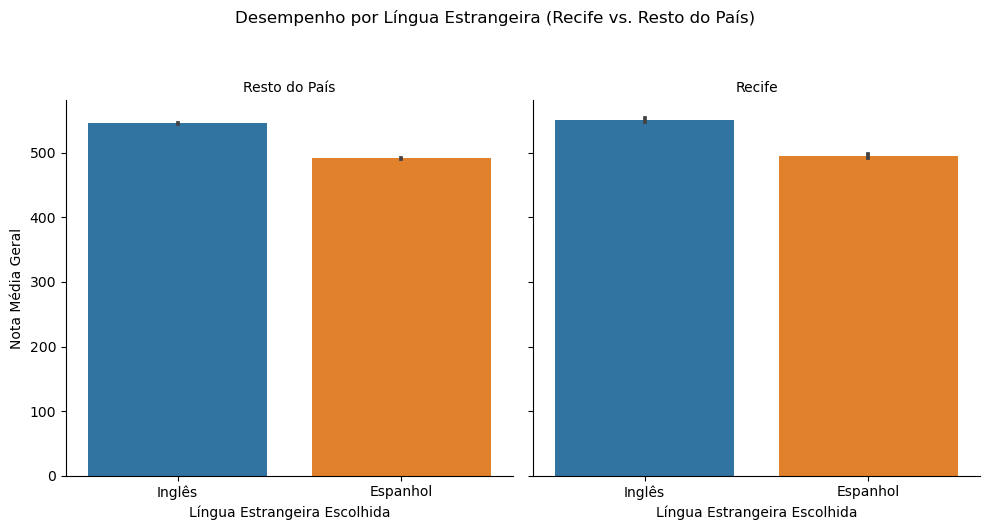

In [18]:
# Lista de provas
provas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
# Filtrar o DataFrame:
# 1. Apenas quem fez as provas (NU_NOTA_TOTAL > 0)
df_analise_lingua = df_enem.query("NU_NOTA_TOTAL > 0").copy()

# Criar a coluna 'LOCALIZACAO' (Recife vs. Resto do País)
df_analise_lingua['LOCALIZACAO'] = np.where(
 df_analise_lingua['NO_MUNICIPIO_PROVA'] == cidade_interesse,
 cidade_interesse,
 'Resto do País'
)
# Criar a métrica de desempenho (Média das notas)
df_analise_lingua['NU_NOTA_MEDIA'] = df_analise_lingua[provas].mean(axis=1)
# --- 1. Mapeamento da Língua Estrangeira ---
mapa_lingua = {
 0: 'Inglês',
 1: 'Espanhol'
}

# Criar a nova coluna descritiva
df_analise_lingua['LINGUA_DESC'] = df_analise_lingua['TP_LINGUA'].map(mapa_lingua)
# Definir a ordem correta para o gráfico
ordem_lingua = ['Inglês', 'Espanhol']
# --- 2. Inspeção Visual (Gráfico de Barras) ---
print("--- Nota Geral Média por Língua Estrangeira ---")

# kind='bar' calcula a média por padrão
g = sns.catplot(
 data=df_analise_lingua,
 x='LINGUA_DESC',
 y='NU_NOTA_MEDIA',
 col='LOCALIZACAO',
 kind='bar',
 order=ordem_lingua,
 height=5,
 aspect=1
)

g.set_titles("{col_name}")
g.set_axis_labels("Língua Estrangeira Escolhida", "Nota Média Geral")
plt.suptitle("Desempenho por Língua Estrangeira (Recife vs. Resto do País)", y=1.05)

# Chamar tight_layout() para garantir que os labels não sejam cortados
plt.tight_layout()
plt.show()

<div class="alert alert-primary">
<b>10.1</b> - Explique os resultados obtidos.
</div>

# Resposta #
Os gráficos de barras mostram uma diferença clara e consistente no desempenho dos alunos com base na língua estrangeira escolhida:

**Em Recife:** Os participantes que escolheram Inglês (TP_LINGUA = 0) como língua estrangeira obtiveram uma nota geral média visivelmente superior (cerca de 540 pontos) em comparação com aqueles que escolheram Espanhol (TP_LINGUA = 1), cuja média foi de aproximadamente 495 pontos.

**No Resto do País:** O padrão é exatamente o mesmo. Os alunos que optaram por Inglês também apresentaram uma média de desempenho superior (cerca de 540 pontos) em relação aos que optaram por Espanhol (média de ~490 pontos).

**Conclusão:** Em ambas as localidades, participantes que escolheram a prova de Inglês tiveram uma nota geral média mais alta do que aqueles que escolheram Espanhol.

<div class="alert alert-info">
    <b>11</b> - Qual a nota geral média dos alunos, de acordo com ocupação dos pais/responsáveis e (<code>Q003</code> e <code>Q004</code>) tanto em sua cidade de interesse quanto no resto do país?
</div>

--- Relação entre Ocupação dos Pais e Desempenho dos Alunos ---


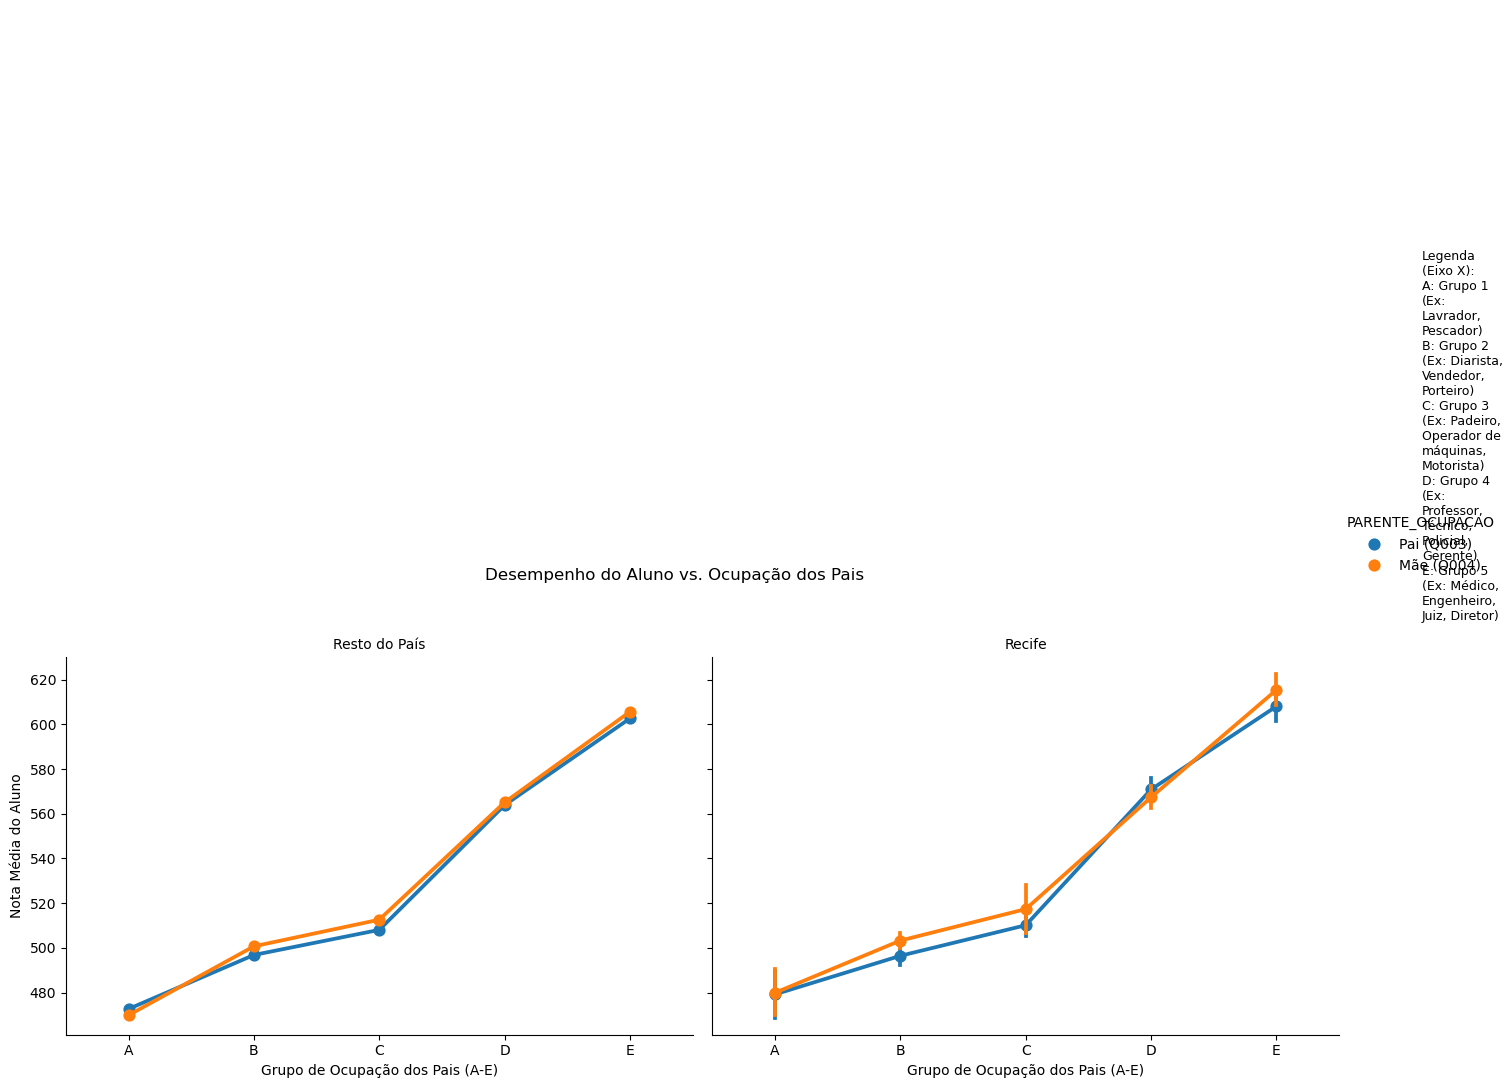

In [19]:
# Lista de provas (garantindo que está definida)
provas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']


# Filtrar o DataFrame:
# 1. Apenas quem fez as provas (NU_NOTA_TOTAL > 0)
df_analise_ocupacao = df_enem.query("NU_NOTA_TOTAL > 0").copy()

# Criar a coluna 'LOCALIZACAO' (Cidade de Interesse vs. Resto do País)
df_analise_ocupacao['LOCALIZACAO'] = np.where(
    df_analise_ocupacao['NO_MUNICIPIO_PROVA'] == cidade_interesse,
    cidade_interesse,
    'Resto do País'
)

# Criar a métrica de desempenho (Média das notas)
df_analise_ocupacao['NU_NOTA_MEDIA'] = df_analise_ocupacao[provas].mean(axis=1)

# Remover a categoria 'F' (Não sei) de ambas as colunas
df_analise_ocupacao = df_analise_ocupacao.query("Q003 != 'F' and Q004 != 'F'").copy()


# Vamos "derreter" (melt) o DataFrame para transformar as colunas Q003 e Q004
# em uma única coluna "PARENTE_OCUPACAO" e outra "GRUPO_OCUPACAO".
df_melted_ocupacao = df_analise_ocupacao.melt(
    id_vars=['LOCALIZACAO', 'NU_NOTA_MEDIA'],
    value_vars=['Q003', 'Q004'],
    var_name='PARENTE_OCUPACAO',
    value_name='GRUPO_OCUPACAO'
)

# Renomear os valores para clareza na legenda do gráfico
df_melted_ocupacao['PARENTE_OCUPACAO'] = df_melted_ocupacao['PARENTE_OCUPACAO'].map({
    'Q003': 'Pai (Q003)',
    'Q004': 'Mãe (Q004)'
})

# --- 3. Definir Ordem e Plotar ---

# Definir a ordem correta das categorias de ocupação (A a E)
ordem_ocupacao = ['A', 'B', 'C', 'D', 'E']

print("--- Relação entre Ocupação dos Pais e Desempenho dos Alunos ---")

# Usar catplot com kind='point'
# 'point' calcula a média e o intervalo de confiança (CI) por padrão
g = sns.catplot(
    data=df_melted_ocupacao,
    x='GRUPO_OCUPACAO',
    y='NU_NOTA_MEDIA',
    hue='PARENTE_OCUPACAO',  # Linhas separadas para Pai e Mãe
    col='LOCALIZACAO',     # Gráficos separados para Cidade e Resto do País
    kind='point',
    order=ordem_ocupacao, # Garante a ordem do eixo X (A, B, C...)
    height=5,              # Altura de cada gráfico
    aspect=1.2             # Proporção (largura = 1.2 * altura)
)

# --- 4. Melhorar Visualização ---
g.set_titles("{col_name}")
g.set_axis_labels("Grupo de Ocupação dos Pais (A-E)", "Nota Média do Aluno")
g.set_xticklabels(rotation=0)
plt.suptitle("Desempenho do Aluno vs. Ocupação dos Pais", y=1.05)

# Adicionar uma legenda para as categorias A-E
legenda_texto_ocupacao = (
    "Legenda (Eixo X):\n"
    "A: Grupo 1 (Ex: Lavrador, Pescador)\n"
    "B: Grupo 2 (Ex: Diarista, Vendedor, Porteiro)\n"
    "C: Grupo 3 (Ex: Padeiro, Operador de máquinas, Motorista)\n"
    "D: Grupo 4 (Ex: Professor, Técnico, Policial, Gerente)\n"
    "E: Grupo 5 (Ex: Médico, Engenheiro, Juiz, Diretor)"
)
# Ajuste a posição (x, y) conforme necessário
plt.figtext(1.05, 0.95, legenda_texto_ocupacao, fontsize=9, wrap=True)

plt.tight_layout()
plt.show()

<div class="alert alert-primary">
<b>11.1</b> - Explique os resultados obtidos.
</div>

## Resposta ##
Os resultados evidenciam uma correlação positiva entre o nível ocupacional dos pais e o desempenho médio dos filhos no ENEM. Ocupações com maior qualificação e estabilidade econômica estão associadas a médias mais altas, tanto em Recife quanto no restante do país, confirmando o impacto do contexto socioeconômico familiar no desempenho escolar.

----
#### Transformação e Engenharia de atributos

<div class="alert alert-info">
    <b>12</b> - A partir do campo <code>NU_IDADE</code>, que armazena a idade dos inscritos, crie a coluna <code>FAIXA_ETARIA</code> com os seguintes intervalos:
    <ul>
        <li>[10..18)</li>
        <li>[18..22)</li>
        <li>[22..26)</li>
        <li>[26..33)</li>
        <li>[33..40)</li>
        <li>[40..55)</li>
        <li>[55..65)</li>
        <li>[65..70)</li>
        <li>[70..100]</li>
    </ul><i>ATENÇÃO</i>: Apague instâncias com idade inferior a 10 ou superior a 100 anos.
</div>

In [20]:
print(f"Shape original: {df_enem.shape}")

df_enem = df_enem.query("NU_IDADE >= 10 and NU_IDADE <= 100").copy()

print(f"Shape após filtrar idades (10-100): {df_enem.shape}")
bins_idade = [10, 18, 22, 26, 33, 40, 55, 65, 70, 101]

# Os rótulos para cada intervalo definido acima.
labels_idade = [
    '[10..18)',
    '[18..22)',
    '[22..26)',
    '[26..33)',
    '[33..40)',
    '[40..55)',
    '[55..65)',
    '[65..70)',
    '[70..100]'
]

# right=False: Garante que os intervalos sejam [fechado..aberto)
df_enem['FAIXA_ETARIA'] = pd.cut(
    df_enem['NU_IDADE'],
    bins=bins_idade,
    labels=labels_idade,
    right=False
)

print("\n--- Verificação da nova coluna FAIXA_ETARIA ---")
print(df_enem['FAIXA_ETARIA'].value_counts().sort_index())

# Verificar se alguma idade ficou de fora (NaN)
nulos_faixa = df_enem['FAIXA_ETARIA'].isnull().sum()
print(f"\nNulos na FAIXA_ETARIA (deve ser 0): {nulos_faixa}")

Shape original: (449165, 57)
Shape após filtrar idades (10-100): (449158, 57)

--- Verificação da nova coluna FAIXA_ETARIA ---
FAIXA_ETARIA
[10..18)     118285
[18..22)     187203
[22..26)      57789
[26..33)      41207
[33..40)      22035
[40..55)      19649
[55..65)       2613
[65..70)        278
[70..100]        99
Name: count, dtype: int64

Nulos na FAIXA_ETARIA (deve ser 0): 0


Considerando apenas os alunos que não faltaram a nenhuma prova (`TP_PRESENCA_**`), queremos tentar prever se um dado inscrito irá obter uma nota de redação acima ou abaixo da média, a partir das seguintes informações:

- `FAIXA_ETARIA`, `NO_MUNICIPIO_RESIDENCIA`, `TP_SEXO`, `TP_ESTADO_CIVIL`, `TP_ST_CONCLUSAO`, `TP_ANO_CONCLUIU`, `TP_ESCOLA`
- `CO_PROVA_CH`,`CO_PROVA_LC`, `NU_NOTA_CH`, `NU_NOTA_LC`, `TP_LINGUA`
- `Q001`, `Q002`, `Q003`, `Q004`, `Q005`, `Q006`, `Q021`, `Q022`, `Q024`, `Q025`
- `TARGET`

<div class="alert alert-info">
<b>13</b> - Prepare os dados para aprendizado, convertendo strings para dados categóricos, mantendo sem mudanças os dados categóricos não numéricos e padronizando dados numéricos usando Z-score.<br><i>ATENÇÃO</i>: Você deve criar a coluna `TARGET` para ser utilizada como alvo de classificação e avaliação de atributos. Ela deve ser `1`, caso a nota da redação do aluno seja maior que a média, ou `0`, caso contrário.
</div>

In [21]:
from sklearn.preprocessing import StandardScaler
# Selecionar apenas alunos presentes em todas as 4 provas objetivas
# (TP_PRESENCA_* == 1 significa 'Presente na prova')

print(f"Shape antes do filtro de presença: {df_enem.shape}")

cols_presenca = ['TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT']
query_presenca = " and ".join([f"{col} == 1" for col in cols_presenca])

# Criamos o DataFrame de ML (Machine Learning)
df_ml = df_enem.query(query_presenca).copy()

print(f"Shape após filtro de presença (alunos presentes): {df_ml.shape}")


# Calcular a média de redação APENAS dos alunos presentes
media_redacao = df_ml['NU_NOTA_REDACAO'].mean()
print(f"\nMédia da Redação (para o TARGET): {media_redacao:.2f}")

# Criar o TARGET: 1 se a nota for MAIOR que a média, 0 caso contrário
df_ml['TARGET'] = (df_ml['NU_NOTA_REDACAO'] > media_redacao).astype(int)

# Verificar o balanceamento do nosso target
print("\nBalanceamento da classe TARGET (0 vs 1):")
print(df_ml['TARGET'].value_counts(normalize=True))


# Lista de colunas (features) conforme solicitado
FEATURES_LIST = [
    'FAIXA_ETARIA', 'NO_MUNICIPIO_RESIDENCIA', 'TP_SEXO', 'TP_ESTADO_CIVIL',
    'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU', 'TP_ESCOLA', 'CO_PROVA_CH',
    'CO_PROVA_LC', 'NU_NOTA_CH', 'NU_NOTA_LC', 'TP_LINGUA',
    'Q001', 'Q002', 'Q003', 'Q004', 'Q005', 'Q006',
    'Q021', 'Q022', 'Q024', 'Q025'
]

# Coluna alvo
TARGET_COL = 'TARGET'

# Separar os DataFrames
X = df_ml[FEATURES_LIST].copy()
y = df_ml[TARGET_COL]

print(f"\nShape de X (features): {X.shape}")
print(f"Shape de y (target): {y.shape}")


print("\n--- Iniciando Pré-processamento ---")

# Identificar os tipos de colunas para aplicar as transformações corretas

#    (Instrução: "convertendo strings para dados categóricos")
#    Usaremos pd.factorize() para convertê-las em números (0, 1, 2...)
cols_string_para_categorizar = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nColunas 'String/Category' para Factorize: {cols_string_para_categorizar}")

for col in cols_string_para_categorizar:
    X[col] = pd.factorize(X[col])[0]

#    (Instrução: "padronizando dados numéricos usando Z-score")
cols_numericas_padronizar = ['NU_NOTA_CH', 'NU_NOTA_LC']
print(f"Colunas 'Numéricas' para Z-Score (StandardScaler): {cols_numericas_padronizar}")

# Inicializar o StandardScaler
scaler = StandardScaler()

# Aplicar o fit_transform (Z-score)
X[cols_numericas_padronizar] = scaler.fit_transform(X[cols_numericas_padronizar])

print("Colunas categóricas numéricas (ex: TP_ESCOLA, Q005...) foram mantidas como estão.")


print("\n--- Processamento Concluído ---")
print("Tipos de dados de X após transformação (deve ser tudo numérico):")
X.info()

print("\nHead de X (features processadas):")
print(X.head())

print("\nHead de y (target):")
print(y.head())

Shape antes do filtro de presença: (449158, 58)
Shape após filtro de presença (alunos presentes): (423321, 58)

Média da Redação (para o TARGET): 597.15

Balanceamento da classe TARGET (0 vs 1):
TARGET
1    0.520428
0    0.479572
Name: proportion, dtype: float64

Shape de X (features): (423321, 22)
Shape de y (target): (423321,)

--- Iniciando Pré-processamento ---

Colunas 'String/Category' para Factorize: ['FAIXA_ETARIA', 'NO_MUNICIPIO_RESIDENCIA', 'TP_SEXO', 'Q001', 'Q002', 'Q003', 'Q004', 'Q006', 'Q021', 'Q022', 'Q024', 'Q025']
Colunas 'Numéricas' para Z-Score (StandardScaler): ['NU_NOTA_CH', 'NU_NOTA_LC']
Colunas categóricas numéricas (ex: TP_ESCOLA, Q005...) foram mantidas como estão.

--- Processamento Concluído ---
Tipos de dados de X após transformação (deve ser tudo numérico):
<class 'pandas.core.frame.DataFrame'>
Index: 423321 entries, 0 to 599981
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   -----------

<div class="alert alert-info">
<b>14</b> - Que atributos são os mais importantes considerando correlação absoluta com o alvo, ANOVA, chi quadrado, Informação Mútua e a importância das variáveis de acordo com uma floresta aleatória? Considere apenas candidatos em sua cidade de interesse.<br><i>Dica</i>: Para facilitar a visualização, coloque todas as métricas em um único dataframe. Então as normalize para que todas fiquem entre 0 e 1. Obtenha então uma média agregada das métricas normalizadas e use esta média agregada para ordenar as variáveis da mais à menos importante.
</div>

In [22]:
from sklearn.feature_selection import f_classif, chi2, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler


indices_cidade = df_ml[df_ml['NO_MUNICIPIO_PROVA'] == cidade_interesse].index

# usando os índices da cidade.
X_city = X.loc[indices_cidade]
y_city = y.loc[indices_cidade]

print(f"Iniciando análise de features para {X_city.shape[0]} participantes de {cidade_interesse}.")
print("Calculando as 5 métricas...")


# Criar o DataFrame de resultados
feature_scores = pd.DataFrame(index=X_city.columns)

# (Usamos .values em y_city para evitar problemas de alinhamento de índice)
df_corr_temp = X_city.copy()
df_corr_temp['TARGET'] = y_city.values
corr_matrix = df_corr_temp.corr()
feature_scores['Correlation'] = corr_matrix['TARGET'].abs().drop('TARGET')

# (Mede a variância entre as médias dos grupos)
anova_f, anova_p = f_classif(X_city, y_city)
feature_scores['ANOVA'] = anova_f

# (Requer dados não-negativos)
# Vamos escalar X_city para [0, 1] *apenas* para este teste
scaler_minmax = MinMaxScaler()
X_city_minmax = scaler_minmax.fit_transform(X_city)
chi2_val, chi2_p = chi2(X_city_minmax, y_city)
feature_scores['Chi2'] = chi2_val

# (Mede a informação que a feature compartilha com o alvo)
mi = mutual_info_classif(X_city, y_city, random_state=42)
feature_scores['MutualInfo'] = mi

# (Mede quanto a feature contribui para a acurácia do modelo)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_city, y_city)
feature_scores['RandomForest'] = rf.feature_importances_

# Lidar com qualquer NaN que possa ter surgido (embora improvável)
feature_scores.fillna(0, inplace=True)

# Normalizar todas as métricas para a escala [0, 1]
scaler_norm = MinMaxScaler()
df_normalized = pd.DataFrame(
    scaler_norm.fit_transform(feature_scores),
    columns=feature_scores.columns,
    index=feature_scores.index
)

# Criar a média agregada
df_normalized['Aggregated_Mean'] = df_normalized.mean(axis=1)

# Ordenar pela média agregada
df_final_ranking = df_normalized.sort_values(by='Aggregated_Mean', ascending=False)

print(f"\n--- Ranking de Features Mais Importantes para {cidade_interesse} ---")
print(df_final_ranking.to_markdown(floatfmt=".4f"))

Iniciando análise de features para 7417 participantes de Recife.
Calculando as 5 métricas...

--- Ranking de Features Mais Importantes para Recife ---
|                         |   Correlation |   ANOVA |   Chi2 |   MutualInfo |   RandomForest |   Aggregated_Mean |
|:------------------------|--------------:|--------:|-------:|-------------:|---------------:|------------------:|
| NU_NOTA_LC              |        1.0000 |  1.0000 | 0.0662 |       1.0000 |         1.0000 |            0.8132 |
| NU_NOTA_CH              |        0.9847 |  0.9617 | 0.1044 |       0.8962 |         0.9148 |            0.7723 |
| Q024                    |        0.5775 |  0.2867 | 0.6865 |       0.3334 |         0.1398 |            0.4048 |
| Q021                    |        0.4409 |  0.1645 | 1.0000 |       0.0986 |         0.0384 |            0.3485 |
| Q002                    |        0.4760 |  0.1921 | 0.3200 |       0.2744 |         0.2139 |            0.2953 |
| Q006                    |        0.3012 | 